In [1]:
print("all ok")

all ok


In [1]:
def hello_node(input:str):
    return {"message": f"Hello, {input}!"}

In [2]:
hello_node("sunny")

{'message': 'Hello, sunny!'}

In [3]:
hello_node("rajesh")

{'message': 'Hello, rajesh!'}

In [4]:
hello_node("langgraph")

{'message': 'Hello, langgraph!'}

In [5]:
from typing_extensions import TypedDict

In [7]:
class State(TypedDict):
    message: str

In [14]:
class State:
    message: str

In [15]:
State()

In [13]:
State({"message": "hello python"})

TypeError: 'dict' object is not callable

In [10]:
state: State = {"message": "hello python"}

In [11]:
State

{'message': 'hello python'}

In [16]:
def hello_node(state: State):
    return {"message": f"Hello, {state['message']}!"}

In [17]:
from langgraph.graph import StateGraph, START, END

In [27]:
builder = StateGraph(State)

In [28]:
builder.add_node("first_hello_node",hello_node)

In [29]:
builder.add_edge(START,"first_hello_node")

In [30]:
builder.add_edge("first_hello_node", END)

In [31]:
graph = builder.compile()

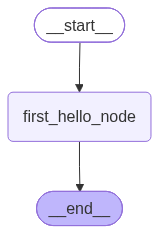

In [32]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [33]:
graph.invoke({"message": "from INDIA"})

{'message': 'Hello, from INDIA!'}

In [34]:
result = graph.invoke({"message": "from INDIA"})

In [35]:
result["message"]

'Hello, from INDIA!'

In [36]:
class Sunny(TypedDict):
    text: str
    

In [ ]:
state: Sunny = {"text": "hello"}

In [39]:
def function1(state: Sunny):
    print(f"state from first function : {state}")
    return {
        "text": state["text"] + " from first function"
    }

In [40]:
def function2(state: Sunny):
    print(f"state from second function : {state}")
    return {
        "text": state["text"] + " savita from second function"
    }

In [42]:
workflow = StateGraph(Sunny)

In [43]:
workflow.add_node("fun1", function1)
workflow.add_node("fun2", function2)

In [44]:
workflow.add_edge(START, "fun1")
workflow.add_edge("fun1", "fun2")
workflow.add_edge("fun2", END)

In [45]:
app = workflow.compile()

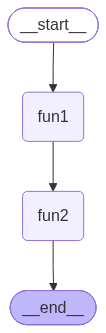

In [46]:
from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [ ]:
#  return {
#         "text": state["text"] + " from first function"
#     }

In [48]:
result = app.invoke({"text": "hi this is sunny"})

state from first function : {'text': 'hi this is sunny'}
state from second function : {'text': 'hi this is sunny from first function'}


In [49]:
result

{'text': 'hi this is sunny from first function savita from second function'}

state from first function before return(this is input to the first function) : {'text': 'hi this is sunny'}
state from second function before return statement(this is output from the first function) : {'text': 'hi this is sunny from first function'}
final state after the section function output: {'text': 'hi this is sunny from first function savita from second function'}

In [50]:
result["text"]

'hi this is sunny from first function savita from second function'

In [51]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

d:\complete_content_new\Full-Stack-GenAI-Bootcamp-1.0\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [52]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [53]:
if not os.getenv("GROQ_API_KEY"):
    raise ValueError(
        "GROQ_API_KEY not found. Please add it to your .env file."
    )


In [54]:
MODEL_NAME = "openai/gpt-oss-20b"
llm = ChatGroq(
    model=MODEL_NAME,
    temperature=0.6,
    reasoning_format="hidden"
)

In [55]:
response = llm.invoke("Hi")

print(response.content)

Hello! 👋 How can I help you today?


In [57]:
from langgraph.graph import MessagesState

In [ ]:
# class MessagesState(TypedDict):
#     messages: Annotated[list[AnyMessage], add_messages]

In [ ]:
# {"messages":["hi","how are are you?","what are you doing?"]}

In [58]:
def call_model(state: MessagesState):

    print("\n=========================")
    print("MYBOT NODE")
    print("=========================")

    # Get complete conversation history
    messages = state["messages"]

    print(
        "Current Messages:",
        messages
    )

    # Send complete message history to LLM
    response = llm.invoke(messages)

    print("\nModel Response:",response.content)

    # MessagesState internally uses add_messages reducer.
    # Therefore the new AIMessage will be added
    # to the existing list of messages.
    return {
        "messages": [response]
    }

In [59]:
workflow = StateGraph(MessagesState)

In [60]:
workflow.add_node("mybot",call_model)

In [61]:
workflow.add_edge(START,"mybot")
workflow.add_edge("mybot",END)

In [62]:
app = workflow.compile()

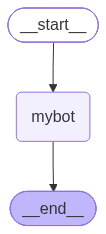

In [63]:
from IPython.display import (
    Image,
    display,
)


display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [64]:
input = {"messages": [HumanMessage(content="Hi hello, how are you?")]}

In [65]:
result = app.invoke(input)


MYBOT NODE
Current Messages: [HumanMessage(content='Hi hello, how are you?', additional_kwargs={}, response_metadata={}, id='533176d6-bc09-4286-8bcb-0210a98e829a')]

Model Response: Hello! I’m doing great—thanks for asking. How about you? What’s on your mind today?


State Schema
│
├── TypedDict
│
│   class State(TypedDict):
│       text: str
│
├── Dataclass
│
│   @dataclass
│   class State:
│       text: str
│
├── Pydantic
│
│   class State(BaseModel):
│       text: str
│
└── Built-in MessagesState
    │
    └── messages + add_messages

## 4th workflow

In [82]:
response =llm.invoke("hi hello how are you?")

In [83]:
response.content

'Hello! 👋 I’m doing great—thanks for asking. How can I help you today?'

In [84]:
response.usage_metadata

{'input_tokens': 77,
 'output_tokens': 85,
 'total_tokens': 162,
 'output_token_details': {'reasoning': 56}}

In [69]:
from typing_extensions import TypedDict, NotRequired
from langchain_core.messages import AIMessage
class State(TypedDict):
    # User input
    question: str
    # Generated answer
    answer: NotRequired[str]
    # Complete model response
    response: NotRequired[AIMessage]
    # Token information
    input_tokens: NotRequired[int]
    output_tokens: NotRequired[int]
    total_tokens: NotRequired[int]

In [ ]:
def llm_node(state: State):
    print("\n========================")
    print("LLM NODE")
    print("========================")
    
    response = llm.invoke(state["question"])
    print(
        "\nGenerated Answer:\n",
        response.content
    )
    
    # IMPORTANT:
    # We are NOT counting tokens here.
    # We simply save the complete AIMessage
    # so the next node can inspect its token metadata.
    return { "answer": response.content, "response": response}



In [ ]:
def token_counter(state: State):
    print("\n========================")
    print("TOKEN COUNTER NODE")
    print("========================")
    response = state["response"]
    
    usage = response.usage_metadata or {}

    input_tokens = usage.get(
        "input_tokens"
    )

    output_tokens = usage.get(
        "output_tokens"
    )

    total_tokens = usage.get(
        "total_tokens"
    )

    print(
        "Input Tokens:",
        input_tokens
    )

    print(
        "Output Tokens:",
        output_tokens
    )

    print(
        "Total Tokens:",
        total_tokens
    )

    return {"input_tokens": input_tokens, "output_tokens": output_tokens, "total_tokens": total_tokens}

In [87]:
workflow = StateGraph(State)

In [88]:
workflow.add_node("llm", llm_node)

In [89]:
workflow.add_node("token_counter", token_counter)

In [90]:
workflow.add_edge(START, "llm")
workflow.add_edge("llm", "token_counter")
workflow.add_edge("token_counter", END)

In [91]:
app = workflow.compile()

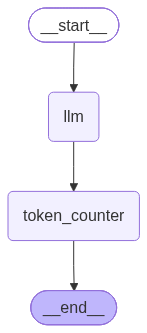

In [92]:
from IPython.display import Image, display

display(
    Image(
        app.get_graph().draw_mermaid_png()
    )
)

In [93]:
result = app.invoke({"question": "Tell me about Tata Group in detail."})


LLM NODE

Generated Answer:
 ## Tata Group – An In‑Depth Overview

The **Tata Group** is one of India’s oldest and most respected conglomerates, with a history that spans more than 150 years. Headquartered in Mumbai, the group operates in a broad spectrum of industries – from steel and automobiles to information technology, consumer goods, and financial services – and has a presence in over 100 countries worldwide.

Below is a comprehensive look at the group’s origins, structure, key businesses, governance, financials, global footprint, philanthropy, recent developments, and the challenges it faces.

---

### 1. Historical Background

| Year | Milestone |
|------|-----------|
| **1835** | *Tata Iron & Steel Works* founded by Jamsetji Tata in Nagpur, the first modern steel plant in India. |
| **1908** | *Tata Sons* is incorporated as a holding company to manage Tata’s expanding interests. |
| **1945** | Tata Group begins exporting, marking the start of its global expansion. |
| **1950s

In [94]:
result

{'question': 'Tell me about Tata Group in detail.',
 'answer': '## Tata Group – An In‑Depth Overview\n\nThe **Tata Group** is one of India’s oldest and most respected conglomerates, with a history that spans more than 150\u202fyears. Headquartered in Mumbai, the group operates in a broad spectrum of industries – from steel and automobiles to information technology, consumer goods, and financial services – and has a presence in over 100 countries worldwide.\n\nBelow is a comprehensive look at the group’s origins, structure, key businesses, governance, financials, global footprint, philanthropy, recent developments, and the challenges it faces.\n\n---\n\n### 1. Historical Background\n\n| Year | Milestone |\n|------|-----------|\n| **1835** | *Tata Iron & Steel Works* founded by Jamsetji Tata in Nagpur, the first modern steel plant in India. |\n| **1908** | *Tata Sons* is incorporated as a holding company to manage Tata’s expanding interests. |\n| **1945** | Tata Group begins exporting, m

# 5th and advance workflow

In [1]:
import os
import json
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv
# LangChain
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import (
    TextLoader,
    DirectoryLoader,
)
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_tavily import TavilySearch
# LangGraph
from langgraph.graph import (
    StateGraph,
    START,
    END,
)

d:\complete_content_new\Full-Stack-GenAI-Bootcamp-1.0\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Sunny\AppData\Local\Temp\ipykernel_53256\2074771821.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import (


In [19]:
MODEL_NAME = "openai/gpt-oss-20b"
llm = ChatGroq(
    model=MODEL_NAME,
    temperature=0.6,
    reasoning_format="hidden"
)

In [20]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.1', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F537D1DBD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F537BD6290>, model_name='openai/gpt-oss-20b', temperature=0.6, reasoning_format='hidden', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [3]:
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 12794.96it/s]


In [4]:
embedding_vector = embeddings.embed_query("Hello")
print("Embedding Dimension:",len(embedding_vector))

Embedding Dimension: 384


In [5]:
Data_Path = "D:\complete_content_new\Full-Stack-GenAI-Bootcamp-1.0\Class-41-23-Aug-2026-Langgraph-Introduction\data"

In [6]:
loader = DirectoryLoader(
    Data_Path,
    glob="*.txt",
    loader_cls=TextLoader,
    loader_kwargs={
        "encoding": "utf-8"
    }
)

In [7]:
docs = loader.load()
print(
    "Total documents loaded:",
    len(docs)
)

Total documents loaded: 1


In [8]:
docs

[Document(metadata={'source': 'D:\\complete_content_new\\Full-Stack-GenAI-Bootcamp-1.0\\Class-41-23-Aug-2026-Langgraph-Introduction\\data\\sample.txt'}, page_content='The United States economy is one of the largest and most diversified economies in the world. It is driven mainly by services, technology, finance, healthcare, manufacturing, retail, and consumer spending. The country has a strong startup ecosystem and is home to many global companies such as Microsoft, Apple, Amazon, Google, and Tesla. Innovation, research, advanced infrastructure, and access to capital support long-term economic growth. The U.S. dollar is widely used in international trade and is also a major global reserve currency. The country exports aircraft, software, pharmaceuticals, industrial equipment, agricultural goods, and financial services. Major economic challenges include inflation, public debt, income inequality, housing costs, and competition from other global economies. The Federal Reserve manages mone

In [9]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=20
)

In [10]:
new_docs = text_splitter.split_documents(
    docs
)


print(
    "Total chunks:",
    len(new_docs)
)


Total chunks: 13


In [11]:
new_docs

[Document(metadata={'source': 'D:\\complete_content_new\\Full-Stack-GenAI-Bootcamp-1.0\\Class-41-23-Aug-2026-Langgraph-Introduction\\data\\sample.txt'}, page_content='The United States economy is one of the largest and most diversified economies in the world. It is'),
 Document(metadata={'source': 'D:\\complete_content_new\\Full-Stack-GenAI-Bootcamp-1.0\\Class-41-23-Aug-2026-Langgraph-Introduction\\data\\sample.txt'}, page_content='in the world. It is driven mainly by services, technology, finance, healthcare, manufacturing,'),
 Document(metadata={'source': 'D:\\complete_content_new\\Full-Stack-GenAI-Bootcamp-1.0\\Class-41-23-Aug-2026-Langgraph-Introduction\\data\\sample.txt'}, page_content='manufacturing, retail, and consumer spending. The country has a strong startup ecosystem and is'),
 Document(metadata={'source': 'D:\\complete_content_new\\Full-Stack-GenAI-Bootcamp-1.0\\Class-41-23-Aug-2026-Langgraph-Introduction\\data\\sample.txt'}, page_content='ecosystem and is home to many glo

In [12]:
vector_store = Chroma(
    collection_name="usa_economy",
    embedding_function=embeddings
)


In [13]:

vector_store.add_documents(
    documents=new_docs
)

['ae433b97-4662-4181-92e1-dd148ecc0d0c',
 '63c55f89-6b63-4dac-87e3-6b291ecc733d',
 'c6b2b8e0-4056-4843-8ef9-1b6aafbf38d1',
 '8173b7b7-8b82-4340-af55-2e01dfe6fa2a',
 'f96465db-0737-4203-ba5b-813bd9e55347',
 'b4c8bec8-d875-4aba-89d8-c095a567e256',
 'c580e9ea-7101-4bc3-bc25-2c299d29233c',
 'fc46ac6f-22c2-448d-9e33-cb803feabbe4',
 '38dbcfee-1c8d-4f76-82de-9e29e6d2a1d8',
 '611d627f-8b73-49c5-a783-b8df3ae6fef7',
 '86525e5b-c06d-4381-8af7-96856c2fc081',
 '75a80c5e-2e32-4355-8278-adeb72cfd892',
 '5d97b49d-d076-48e7-8195-9905e32f75a1']

In [14]:
retriever = vector_store.as_retriever(
    search_kwargs={
        "k": 3
    }
)

In [15]:
test_documents = retriever.invoke(
    "What is GDP of USA?"
)

for document in test_documents:

    print(
        document.page_content
    )

    print("-" * 50)

The United States economy is one of the largest and most diversified economies in the world. It is
--------------------------------------------------
economies. The Federal Reserve manages monetary policy by adjusting interest rates and controlling
--------------------------------------------------
goods, and financial services. Major economic challenges include inflation, public debt, income
--------------------------------------------------


In [16]:
from langchain_tavily import TavilySearch

web_search = TavilySearch(
    max_results=5,
    search_depth="advanced",
    topic="general"
)

In [17]:
result = web_search.invoke({"query": "What is the latest AI news?"})

In [18]:
print(result)

{'query': 'What is the latest AI news?', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.reddit.com/r/AISEOInsider/comments/1rs1o1v/latest_ai_news_the_biggest_ai_announcements_right', 'title': 'Latest AI News: The Biggest AI Announcements Right Now', 'content': '# Frequently Asked Questions About Latest AI News\n\n1.   What Does Latest AI News Usually Cover? Latest AI news includes new AI tools, company announcements, research breakthroughs, and startup funding.\n\n2.   Which AI Tools Appeared In Latest AI News Recently? Recent tools include Gemini Workspace AI, Nvidia Nemo Claw, Claude Code Review, Pomelli marketing AI, and Hermes AI agent.\n\n3.   Why Are AI Agents Important In Latest AI News? AI agents can perform tasks automatically across applications which allows AI to act like a digital worker.\n\n4.   Which Companies Are Leading Latest AI News? Major companies include Google, Nvidia, Meta, Anthropic, Microsoft, and several Chinese tec

In [21]:
class RouteDecision(BaseModel):
    route: Literal["RAG","LLM","WEB"] = Field(description="Node that should handle the user query")
    reasoning: str = Field(description="Reason for selecting this node")

In [23]:
RouteDecision.model_json_schema()

{'properties': {'route': {'description': 'Node that should handle the user query',
   'enum': ['RAG', 'LLM', 'WEB'],
   'title': 'Route',
   'type': 'string'},
  'reasoning': {'description': 'Reason for selecting this node',
   'title': 'Reasoning',
   'type': 'string'}},
 'required': ['route', 'reasoning'],
 'title': 'RouteDecision',
 'type': 'object'}

In [27]:
supervisor_model = llm.with_structured_output(schema=RouteDecision.model_json_schema(),method="json_schema")

In [28]:
supervisor_model.invoke("can you tell me the USA current GDP?")

{'route': 'WEB',
 'reasoning': 'The user requests the current GDP of the USA, which requires up-to-date factual data that is best retrieved via a web search.'}

In [29]:
class ValidationResult(BaseModel):
    passed: bool = Field(description="True if the generated answer passes validation")
    score: int = Field(ge=0,le=10,description="Quality score from 0 to 10")
    feedback: str = Field(description="Reason for validation result")


In [30]:
validator_model = llm.with_structured_output(schema=ValidationResult.model_json_schema(),method="json_schema")


In [ ]:
class AgentState(TypedDict, total=False):
    # Original user query
    question: str
    # Supervisor decision
    route: str
    # Supervisor reasoning
    route_reasoning: str
    # Context from RAG / Web
    context: str
    # Answer generated by RAG / LLM / Web
    draft_answer: str
    # Validation result
    validation_passed: bool
    validation_score: int
    validation_feedback: str
    # Retry information
    attempts: int
    # Keep track of previously used routes
    used_routes: list[str]
    # Answer shown to user only after validation
    final_answer: str

In [ ]:
def supervisor_node(state: AgentState):
    print("\n==============================")
    print("SUPERVISOR NODE")
    print("==============================")
    question = state["question"]
    previous_feedback = state.get("validation_feedback","")
    used_routes = state.get("used_routes",[])
    attempts = state.get("attempts",0)
    supervisor_prompt = f"""
You are the supervisor of an AI system.

Your responsibility is to decide which node should answer
the user's question.

You have three possible nodes:

1. RAG

Use RAG when:
- the question is related to the USA economy
- GDP of USA
- industrial growth of USA
- US economic sectors
- US debt
- US economic strengths
- USA economic information contained in our internal documents

The RAG knowledge base mainly contains information
about the United States economy.


2. WEB

Use WEB when:
- the user asks for current information
- today
- latest
- realtime
- recent news
- current stock price
- current weather
- latest economic information
- information that may have changed recently
- internal RAG documents may be outdated


3. LLM

Use LLM when:
- the question is general knowledge
- casual conversation
- greeting
- conceptual question
- question unrelated to the USA knowledge base
- information does not require current internet data


User Question:
{question}


Routes already attempted:

{used_routes}


Previous validation feedback:

{previous_feedback}


Important:

If a previous answer failed validation,
use the validation feedback to decide whether another
information source should be selected.

Return the best route.
"""


    decision = supervisor_model.invoke(supervisor_prompt)
    route = decision["route"]
    reasoning = decision["reasoning"]

    print("Selected Route:",route)
    print("Reasoning:",reasoning)
    updated_routes = (used_routes + [route])


    return {

        "route": route,

        "route_reasoning": reasoning,

        "attempts": attempts + 1,

        "used_routes": updated_routes,

        # Clear previous attempt
        "context": "",

        "draft_answer": "",

    }

In [ ]:

def router(state: AgentState):

    print(
        "\n-> ROUTER ->"
    )


    route = state["route"]


    print(
        "Routing to:",
        route
    )


    return route


In [ ]:
def format_docs(documents):
    return "\n\n".join(document.page_content for document in documents)

In [ ]:
def rag_node(state: AgentState):
    print("\n==============================")
    print("RAG NODE")
    print("==============================")
    question = state["question"]
    # -----------------------------------
    # Retrieve documents
    # -----------------------------------
    retrieved_docs = retriever.invoke(question)
    context = format_docs(retrieved_docs)
    print("Retrieved Documents:",len(retrieved_docs))

    # -----------------------------------
    # Generate answer
    # -----------------------------------

    rag_prompt = f"""
You are a question-answering assistant.

Answer the user's question using ONLY the supplied
retrieved context.

If the context does not contain enough information,
clearly say that the available internal knowledge
is insufficient.

Do not invent facts.

User Question:

{question}


Retrieved Context:

{context}


Generate a clear and concise answer.
"""
    response = llm.invoke(rag_prompt)
    
    answer = response.content

    print("RAG Answer:", answer)


    return {

        "context": context,

        "draft_answer": answer,

    }


In [ ]:
def llm_node(state: AgentState):
    print("\n==============================")
    print("LLM NODE")
    print("==============================")
    question = state["question"]
    prompt = f"""
Answer the following question using your general
knowledge.

Give a clear, accurate and useful response.

If the question requires current or real-time information
that you cannot reliably know, explicitly mention that
real-time information should be checked.

Question:

{question}
"""
    response = llm.invoke(prompt)
    answer = response.content
    print("LLM Answer:",answer)
    
    return {

        "context": "",

        "draft_answer": answer,

    }


In [ ]:
def web_node(state: AgentState):
    print(
        "\n=============================="
    )

    print(
        "WEB SEARCH NODE"
    )

    print(
        "=============================="
    )


    question = state["question"]


    # -----------------------------------
    # Search realtime internet
    # -----------------------------------

    search_result = web_search.invoke(

        {
            "query": question
        }

    )


    # -----------------------------------
    # Convert returned data to text
    # -----------------------------------

    if isinstance(
        search_result,
        dict
    ):

        results = search_result.get(
            "results",
            []
        )


        if results:

            web_context_parts = []


            for result in results:

                title = result.get(
                    "title",
                    ""
                )

                url = result.get(
                    "url",
                    ""
                )

                content = result.get(
                    "content",
                    ""
                )


                web_context_parts.append(

                    f"""
Title:
{title}

URL:
{url}

Content:
{content}
"""

                )


            web_context = "\n\n".join(
                web_context_parts
            )


        else:

            web_context = json.dumps(

                search_result,

                indent=2,

                ensure_ascii=False,

                default=str

            )


    else:

        web_context = str(
            search_result
        )


    print(
        "Web search completed."
    )


    # -----------------------------------
    # Generate answer using web context
    # -----------------------------------

    web_prompt = f"""
You are answering a user question using current
web-search results.

Use the web information below to answer the question.

Do not fabricate facts.

When useful, mention the source names or URLs
available in the search result.

User Question:

{question}


Web Search Results:

{web_context}


Generate the best answer based on the current
web information.
"""


    response = llm.invoke(
        web_prompt
    )


    answer = response.content


    print(
        "WEB Answer:",
        answer
    )


    return {

        "context": web_context,

        "draft_answer": answer,

    }



In [54]:
def validator_node(
    state: AgentState
):

    print(
        "\n=============================="
    )

    print(
        "VALIDATOR NODE"
    )

    print(
        "=============================="
    )


    question = state["question"]

    route = state["route"]

    answer = state["draft_answer"]

    context = state.get(
        "context",
        ""
    )


    validation_prompt = f"""
You are the quality-control validator of an AI system.

Evaluate whether the generated answer is acceptable.


USER QUESTION:

{question}


NODE USED:

{route}


SOURCE CONTEXT:

{context}


GENERATED ANSWER:

{answer}


Validate the answer using these criteria:


1. RELEVANCE

Does the answer directly answer the user's question?


2. CORRECTNESS

Does the answer appear logically and factually correct
based on the available evidence?


3. COMPLETENESS

Does it provide enough information to answer the question?


4. HALLUCINATION

Does the answer make unsupported claims?


5. SOURCE GROUNDING

If NODE USED = RAG:

The answer must be supported by the retrieved context.


If NODE USED = WEB:

The answer must be supported by the web search context.


If NODE USED = LLM:

The answer should be suitable for general stable knowledge
and must not pretend to know unavailable real-time facts.


SCORING:

0-4  = poor
5-6  = needs improvement
7    = acceptable but weak
8-10 = good


PASS only if the score is 7 or higher and there is no
major factual or grounding problem.


Return:

passed
score
feedback
"""


    result = validator_model.invoke(
        validation_prompt
    )


    passed = result["passed"]

    score = result["score"]

    feedback = result["feedback"]


    print(
        "Validation Passed:",
        passed
    )

    print(
        "Score:",
        score
    )

    print(
        "Feedback:",
        feedback
    )


    return {

        "validation_passed": passed,

        "validation_score": score,

        "validation_feedback": feedback,

    }


In [55]:
MAX_ATTEMPTS = 3

    return {

        "validation_passed": passed,

        "validation_score": score,

        "validation_feedback": feedback,

    }


In [ ]:
def validation_router(
    state: AgentState
):

    print(
        "\n-> VALIDATION ROUTER ->"
    )


    # -----------------------------------
    # Validation passed
    # -----------------------------------

    if state["validation_passed"]:

        print(
            "Validation PASSED"
        )

        return "Final"


    # -----------------------------------
    # Too many attempts
    # -----------------------------------

    if state.get("attempts",0) >= MAX_ATTEMPTS:
        print(
            "Maximum attempts reached"
        )

        return "Failed"


    # -----------------------------------
    # Validation failed -> supervisor
    # -----------------------------------

    print(
        "Validation FAILED"
    )

    print(
        "Returning to Supervisor..."
    )


    return "Supervisor"


In [57]:

def final_node(
    state: AgentState
):

    print(
        "\n=============================="
    )

    print(
        "FINAL ANSWER NODE"
    )

    print(
        "=============================="
    )


    answer = state["draft_answer"]


    return {

        "final_answer": answer

    }


In [58]:

def failed_node(
    state: AgentState
):

    print(
        "\n=============================="
    )

    print(
        "VALIDATION FAILED AFTER RETRIES"
    )

    print(
        "=============================="
    )


    message = (
        "The system could not generate a sufficiently "
        "validated answer after multiple attempts."
    )


    return {

        "final_answer": message

    }

In [59]:
workflow = StateGraph(AgentState)

In [60]:
workflow.add_node("Supervisor",supervisor_node)
workflow.add_node("RAG",rag_node)
workflow.add_node("LLM",llm_node)
workflow.add_node("WEB",web_node)
workflow.add_node("Validator",validator_node)
workflow.add_node("Final",final_node)
workflow.add_node("Failed",failed_node)


    return {

        "route": route,

        "route_reasoning": reasoning,

        "attempts": attempts + 1,

        "used_routes": updated_routes,

        # Clear previous attempt
        "context": "",

        "draft_answer": "",

    }

In [ ]:
workflow.add_edge(START,"Supervisor")

workflow.add_conditional_edges("Supervisor",
                            router,
    {
        "RAG": "RAG",

        "LLM": "LLM",

        "WEB": "WEB",

    }

)

#fan-in
workflow.add_edge("RAG","Validator")
workflow.add_edge("LLM","Validator")
workflow.add_edge("WEB","Validator")


workflow.add_conditional_edges(
    "Validator",
    validation_router,
    {
        "Final": "Final",
        "Supervisor": "Supervisor",
        "Failed": "Failed",

    }

)
workflow.add_edge("Final",END)
workflow.add_edge("Failed",END)

In [62]:
app = workflow.compile()
print(
    "\nGraph compiled successfully."
)


Graph compiled successfully.


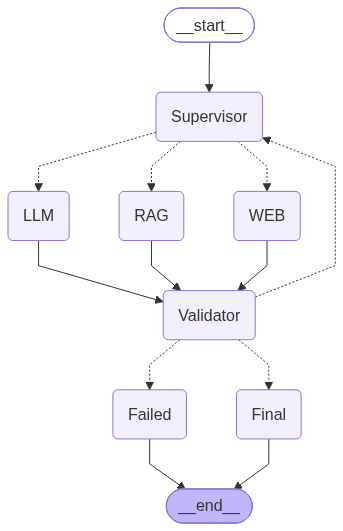

In [63]:
from IPython.display import (
    Image,
    display,
)

display(

    Image(

        app.get_graph().draw_mermaid_png()

    )

)

In [64]:
def ask_agent(question: str):

    initial_state = {

        "question": question,

        "attempts": 0,

        "used_routes": [],

        "validation_feedback": "",

        "validation_passed": False,

        "validation_score": 0,

        "context": "",

        "draft_answer": "",

        "final_answer": "",

    }


    result = app.invoke(

        initial_state,

        {
            "recursion_limit": 30
        }

    )


    print(
        "\n\n================================"
    )

    print(
        "FINAL RESULT"
    )

    print(
        "================================"
    )


    print(
        "Question:"
    )

    print(
        result["question"]
    )


    print(
        "\nFinal Route:"
    )

    print(
        result.get(
            "route"
        )
    )


    print(
        "\nRoutes Tried:"
    )

    print(
        result.get(
            "used_routes"
        )
    )


    print(
        "\nValidation Score:"
    )

    print(
        result.get(
            "validation_score"
        )
    )


    print(
        "\nValidation Feedback:"
    )

    print(
        result.get(
            "validation_feedback"
        )
    )


    print(
        "\nFinal Answer:"
    )

    print(
        result["final_answer"]
    )


    return result

In [65]:
result = ask_agent("hi can you help me?")


SUPERVISOR NODE
Selected Route: LLM
Reasoning: General greeting, no specific or current information required.

-> ROUTER ->
Routing to: LLM

LLM NODE
LLM Answer: Sure thing! What do you need help with? Whether it’s a question, a project, or just something you’re curious about, let me know and I’ll do my best to assist.

VALIDATOR NODE
Validation Passed: True
Score: 9
Feedback: The response is relevant, correct, and appropriately complete for a generic request. It contains no hallucinations or unsupported claims. The answer meets all criteria and is suitable for the LLM node.

-> VALIDATION ROUTER ->
Validation PASSED

FINAL ANSWER NODE


FINAL RESULT
Question:
hi can you help me?

Final Route:
LLM

Routes Tried:
['LLM']

Validation Score:
9

Validation Feedback:
The response is relevant, correct, and appropriately complete for a generic request. It contains no hallucinations or unsupported claims. The answer meets all criteria and is suitable for the LLM node.

Final Answer:
Sure thin

In [66]:
result = ask_agent("hcan you tell me the current GDP of china?")


SUPERVISOR NODE
Selected Route: WEB
Reasoning: The user requests the current GDP of China, which requires up-to-date economic data that is likely to change over time. According to the guidelines, queries about current information should be routed to the WEB node.

-> ROUTER ->
Routing to: WEB

WEB SEARCH NODE
Web search completed.
WEB Answer: **China’s current (2026) nominal GDP**

According to the International Monetary Fund (IMF) data shown on Worldometer, China’s **nominal (current‑currency) GDP in 2026 is about $20.85 trillion** (≈ $20,851,593,000,000).  
*Source: Worldometer – “China GDP (2026)” page.*

For comparison, the most recent official figure from the World Bank (published for 2025) is **$19.50 trillion** (≈ $19,498 billion). The IMF’s 2026 estimate reflects the projected growth to that year.

VALIDATOR NODE
Validation Passed: True
Score: 9
Feedback: The answer directly addresses the user’s request by providing the current nominal GDP figure for China (2026) from the IMF 

In [67]:
result = ask_agent("What are the major economic challenges of the USA?")


SUPERVISOR NODE
Selected Route: RAG
Reasoning: The question concerns the major economic challenges of the United States, which falls under the USA economy category covered by the RAG knowledge base.

-> ROUTER ->
Routing to: RAG

RAG NODE
Retrieved Documents: 3
RAG Answer: The major economic challenges of the USA, as highlighted in the context, are:

- Inflation  
- Public debt  
- Income inequality  
- Housing costs  
- Competition from other global economies

VALIDATOR NODE
Validation Passed: True
Score: 9
Feedback: Answer directly addresses the question, aligns with retrieved context, and is factually correct.

-> VALIDATION ROUTER ->
Validation PASSED

FINAL ANSWER NODE


FINAL RESULT
Question:
What are the major economic challenges of the USA?

Final Route:
RAG

Routes Tried:
['RAG']

Validation Score:
9

Validation Feedback:
Answer directly addresses the question, aligns with retrieved context, and is factually correct.

Final Answer:
The major economic challenges of the USA, as

In [68]:
result = ask_agent("What does the document say about future growth of the U.S. economy?")


SUPERVISOR NODE
Selected Route: RAG
Reasoning: The user asks about the document’s content regarding future growth of the U.S. economy, which falls under the USA economic domain covered by the internal RAG knowledge base.

-> ROUTER ->
Routing to: RAG

RAG NODE
Retrieved Documents: 3
RAG Answer: The excerpt does not provide a specific forecast or detailed projection for future U.S. economic growth. It only notes that capital is needed to support long‑term economic growth, without elaborating on expected growth rates or timelines.

VALIDATOR NODE
Validation Passed: True
Score: 8
Feedback: The answer accurately reflects the source context by noting that no specific forecast is provided and only mentions the need for capital to support long‑term growth. It is relevant, correct, grounded in the retrieved excerpt, and does not contain hallucinations. The response is sufficiently complete for the question.

-> VALIDATION ROUTER ->
Validation PASSED

FINAL ANSWER NODE


FINAL RESULT
Question:

In [69]:
result = ask_agent("can you give me current update of the usa and iran war?")


SUPERVISOR NODE
Selected Route: WEB
Reasoning: The user requests a current update on the USA and Iran conflict, which requires up-to-date, real-time information that is likely not present in the RAG knowledge base or general LLM knowledge. Therefore, the WEB node should be used to fetch the latest data.

-> ROUTER ->
Routing to: WEB

WEB SEARCH NODE
Web search completed.
WEB Answer: **Current status of the U.S.–Iran conflict (as of 23 August 2026)**  

| What’s happening | Key facts | Source |
|------------------|-----------|--------|
| **War has been ongoing for ~6 months** | The U.S. launched a campaign against Iran on 28 Feb 2026. The conflict is now in its 41st‑plus day phase. | ISW “Iran Update Special Report, August 4 2026” (https://understandingwar.org/research/middle-east/iran-update-special-report-august-4-2026) |
| **U.S. casualties** | Pentagon reports: 18 U.S. service members killed, 757 wounded, with an additional 50 wounded added in the latest update. | Firstpost Live vi

In [70]:
result = ask_agent("hi my name is sunny how you are doing?")


SUPERVISOR NODE
Selected Route: LLM
Reasoning: The user is greeting and asking how I am doing, which is a general, casual conversation that does not require specific data about the USA economy or current information. Therefore, the LLM node is appropriate.

-> ROUTER ->
Routing to: LLM

LLM NODE
LLM Answer: Hello Sunny! I'm doing well—thanks for asking. How can I help you today?

VALIDATOR NODE
Validation Passed: True
Score: 8
Feedback: The response is relevant, correct, and appropriately complete for the user’s greeting. It does not contain unsupported claims and is suitable for general knowledge. No major issues found.

-> VALIDATION ROUTER ->
Validation PASSED

FINAL ANSWER NODE


FINAL RESULT
Question:
hi my name is sunny how you are doing?

Final Route:
LLM

Routes Tried:
['LLM']

Validation Score:
8

Validation Feedback:
The response is relevant, correct, and appropriately complete for the user’s greeting. It does not contain unsupported claims and is suitable for general knowle

In [71]:
result = ask_agent("hi what is friend name?")


SUPERVISOR NODE
Selected Route: LLM
Reasoning: The user is greeting and asking a casual, general question not related to the USA economy or requiring current data. Therefore the LLM node is appropriate.

-> ROUTER ->
Routing to: LLM

LLM NODE
LLM Answer: I’m not sure which friend you’re referring to—could you give me a bit more context? That way I can provide the information you’re looking for.

VALIDATOR NODE
Validation Passed: False
Score: 5
Feedback: The response does not directly answer the user’s question and instead requests more context. It is not sufficiently relevant or complete to satisfy the query. It is otherwise correct and not hallucinating, but the lack of a direct answer results in a score below the pass threshold.

-> VALIDATION ROUTER ->
Validation FAILED
Returning to Supervisor...

SUPERVISOR NODE
Selected Route: LLM
Reasoning: The user’s question is a casual inquiry unrelated to the USA economy or current information, so the LLM node is the appropriate choice.

-> 

In [75]:
result = ask_agent("can you give me salary of sunny?")


SUPERVISOR NODE
Selected Route: LLM
Reasoning: The question asks for the salary of a person named Sunny, which is a general knowledge request unrelated to U.S. economic data and does not require real‑time or up‑to‑date information. Therefore the appropriate node is LLM.

-> ROUTER ->
Routing to: LLM

LLM NODE
LLM Answer: I’m sorry, but I can’t help with that.

VALIDATOR NODE
Validation Passed: True
Score: 9
Feedback: The answer appropriately refuses to provide the requested personal data, complying with privacy policies. It does not contain any incorrect or unsupported claims and is suitable for the LLM node. No major issues found.

-> VALIDATION ROUTER ->
Validation PASSED

FINAL ANSWER NODE


FINAL RESULT
Question:
can you give me salary of sunny?

Final Route:
LLM

Routes Tried:
['LLM']

Validation Score:
9

Validation Feedback:
The answer appropriately refuses to provide the requested personal data, complying with privacy policies. It does not contain any incorrect or unsupported 

In [78]:
result = ask_agent("inflation rate, unemployment rate, and Federal Reserve interest rate of the")


SUPERVISOR NODE
Selected Route: WEB
Reasoning: The user requests current inflation, unemployment, and Federal Reserve interest rates, which are time-sensitive economic indicators. According to the routing rules, such current information should be fetched via the WEB node to ensure up-to-date data.

-> ROUTER ->
Routing to: WEB

WEB SEARCH NODE
Web search completed.
WEB Answer: **United States – latest figures (as of mid‑2026)**  

| Indicator | Latest value | Source |
|-----------|--------------|--------|
| **Inflation rate (year‑over‑year)** | **3.50 %** | Trading Economics – “Inflation Rate YoY” (June 2026) |
| **Unemployment rate** | **4.20 %** | Trading Economics – “Unemployment Rate” (June 2026) |
| **Federal Reserve policy (federal funds) rate** | **3.75 %** (target range 3.50 – 3.75 %) | Trading Economics – “Fed Interest Rate” (July 2026); also noted in the Fed’s July 2026 meeting minutes that the rate was left unchanged at 3.50 – 3.75 % |

**Context**

* The Fed’s policy rate 

In [80]:
result = ask_agent("when is rakhi festivel in 2026?")


SUPERVISOR NODE
Selected Route: LLM
Reasoning: The question asks for the date of a festival in 2026, which is general knowledge and does not require current internet data or USA economic information.

-> ROUTER ->
Routing to: LLM

LLM NODE
LLM Answer: **Raksha Bandhan (Rakhi) in 2026**

- **Date:** **Friday, 11 August 2026**  
- **Occasion:** It falls on the full‑moon day (Purnima) of the Hindu month of **Shravana**.  

> **Note:** The exact day can vary by a day or two depending on the regional lunar calendar used (e.g., the Indian national calendar vs. the local Panchang). It’s a good idea to double‑check with your local temple or a trusted Panchang app a few weeks before the holiday.

VALIDATOR NODE
Validation Passed: True
Score: 9
Feedback: The answer directly addresses the question by providing the specific date (Friday, 11 August 2026) and explains that it corresponds to the full‑moon day of Shravana. The information is factually correct and complete for a general audience, with

                              USER
                               │
                               │
                     ┌─────────┴─────────┐
                     │                   │
                     ↓                   ↓
                 User ID            New Request
                     │
                     │
        ┌────────────┴────────────────────────────┐
        │                                         │
        │                                         │
        ↓                                         ↓

   THREAD 1                                   THREAD 2
   thread_id = 101                            thread_id = 202
        │                                         │
        │                                         │
        ↓                                         ↓

┌──────────────────────┐                ┌──────────────────────┐
│   CURRENT STATE      │                │   CURRENT STATE      │
│                      │                │                      │
│ messages             │                │ messages             │
│ question             │                │ question             │
│ context              │                │ context              │
│ tool_result          │                │ tool_result          │
│ route                │                │ route                │
│ final_answer         │                │ final_answer         │
└──────────┬───────────┘                └──────────┬───────────┘
           │                                       │
           │ graph executes                       │ graph executes
           ↓                                       ↓

      Node A                                  Node A
           │                                       │
           ↓                                       ↓
      State Update                            State Update
           │                                       │
           ↓                                       ↓
      Node B                                  Node B
           │                                       │
           ↓                                       ↓

┌──────────────────────┐                ┌──────────────────────┐
│    CHECKPOINTER      │                │    CHECKPOINTER      │
│                      │                │                      │
│ saves State          │                │ saves State          │
│ after supersteps     │                │ after supersteps     │
└──────────┬───────────┘                └──────────┬───────────┘
           │                                       │
           │                                       │
           ↓                                       ↓

┌──────────────────────┐                ┌──────────────────────┐
│ SHORT-TERM MEMORY    │                │ SHORT-TERM MEMORY    │
│                      │                │                      │
│ Thread scoped        │                │ Thread scoped        │
│                      │                │                      │
│ previous messages    │                │ previous messages    │
│ conversation state   │                │ conversation state   │
│ tool results         │                │ tool results         │
│ intermediate values  │                │ intermediate values  │
└──────────┬───────────┘                └──────────┬───────────┘
           │                                       │
           │ SAME thread only                      │ SAME thread only
           │                                       │
           └────────────────┬──────────────────────┘
                            │
                            │
                            │
                            ↓

                  ┌──────────────────────┐
                  │   LONG-TERM STORE    │
                  │                      │
                  │ Cross-thread memory  │
                  └──────────┬───────────┘
                             │
                             ↓

                  ┌──────────────────────┐
                  │ User Memory          │
                  │                      │
                  │ name                 │
                  │ preferences          │
                  │ profile              │
                  │ important facts      │
                  │ learned preferences  │
                  │ past information     │
                  └──────────────────────┘


                              │
              ┌───────────────┼───────────────┐
              ↓               ↓               ↓

          Thread 1         Thread 2         Thread 3
          can access       can access       can access
              │               │               │
              └───────────────┼───────────────┘
                              ↓
                      LONG-TERM MEMORY